# Phase 1 — Exploratory Data Analysis

Goal: understand the class imbalance, amount distributions, and (most importantly) whether fraud rate shifts over time in this dataset, before we build any model.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_raw

df = load_raw()
print('shape:', df.shape)
df.head()

shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Class balance

This is the number that justifies banning accuracy as a metric later: if fraud is ~0.17% of transactions, a model that predicts "not fraud" for everything scores ~99.8% accuracy while catching zero fraud.

Class
0    284315
1       492
Name: count, dtype: int64
fraud rate: 0.1727%
accuracy of a dummy "always predict not-fraud" classifier: 99.8273%


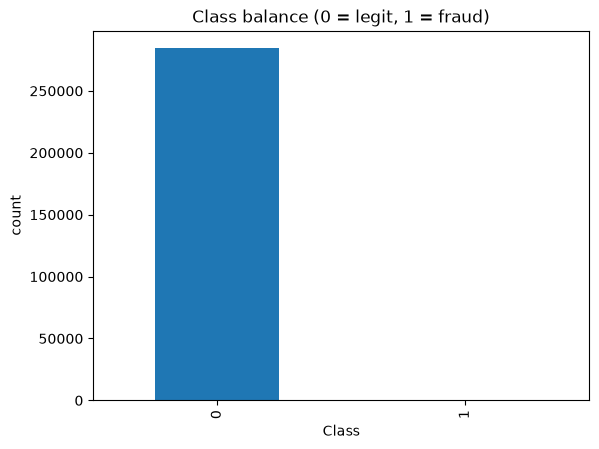

In [2]:
counts = df['Class'].value_counts()
fraud_rate = df['Class'].mean()
print(counts)
print(f'fraud rate: {fraud_rate:.4%}')
print(f'accuracy of a dummy "always predict not-fraud" classifier: {1 - fraud_rate:.4%}')

counts.plot(kind='bar', title='Class balance (0 = legit, 1 = fraud)')
plt.ylabel('count')
plt.show()

## Amount distribution by class

Does fraud tend to happen at noticeably different transaction amounts than legitimate activity? If so, `Amount` alone already carries some useful signal.

In [3]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


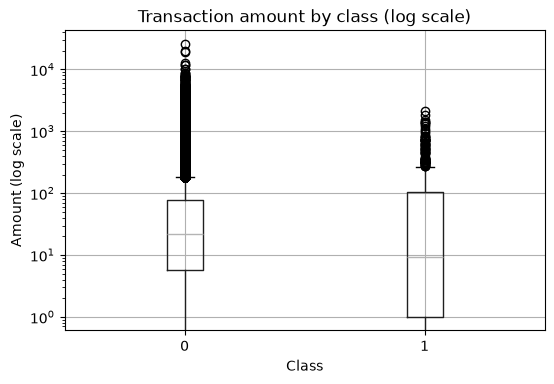

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column='Amount', by='Class', ax=ax)
ax.set_yscale('log')
plt.suptitle('')
ax.set_title('Transaction amount by class (log scale)')
ax.set_ylabel('Amount (log scale)')
plt.show()

## Fraud rate over time (hourly bins)

`Time` is seconds elapsed since the first transaction, covering ~48 hours total — there's no real calendar timestamp. Binning it into hourly windows and plotting transaction volume and fraud rate per hour is our proxy for a timeline. This chart is the one that motivates Phase 3 (concept drift): if fraud rate visibly moves around across these bins, that's early evidence the fraud "pattern" isn't static even within this short window.

In [5]:
df['Hour'] = (df['Time'] // 3600).astype(int)

hourly = df.groupby('Hour').agg(n_transactions=('Class', 'size'), n_fraud=('Class', 'sum'))
hourly['fraud_rate'] = hourly['n_fraud'] / hourly['n_transactions']
hourly

,n_transactions,n_fraud,fraud_rate
Hour,,,
0,3963,2,0.000505
1,2217,2,0.000902
2,1576,21,0.013325
3,1821,13,0.007139
4,1082,6,0.005545
5,1681,11,0.006544
6,1831,3,0.001638
7,3368,23,0.006829
8,5179,5,0.000965


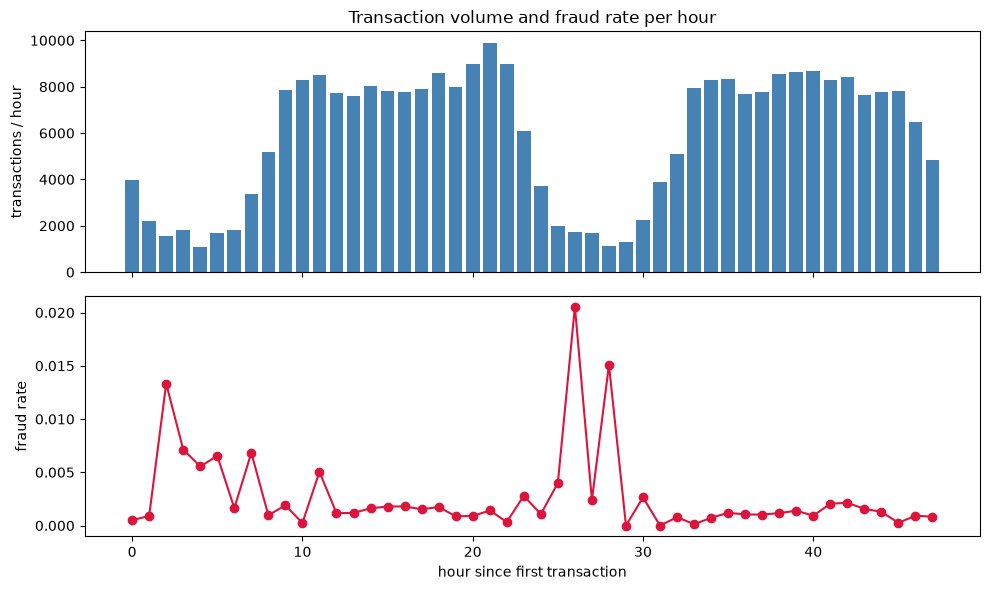

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].bar(hourly.index, hourly['n_transactions'], color='steelblue')
axes[0].set_ylabel('transactions / hour')
axes[0].set_title('Transaction volume and fraud rate per hour')

axes[1].plot(hourly.index, hourly['fraud_rate'], marker='o', color='crimson')
axes[1].set_ylabel('fraud rate')
axes[1].set_xlabel('hour since first transaction')

plt.tight_layout()
plt.show()

## Do the anonymized V1-V28 features separate the classes?

`V1`-`V28` are PCA components — we don't know what they represent physically, so we won't try to interpret them. We just want to confirm they carry signal: which ones correlate most with `Class`?

In [7]:
v_cols = [f'V{i}' for i in range(1, 29)]
corr_with_class = df[v_cols].corrwith(df['Class']).sort_values(key=abs, ascending=False)
corr_with_class.head(10)

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
dtype: float64

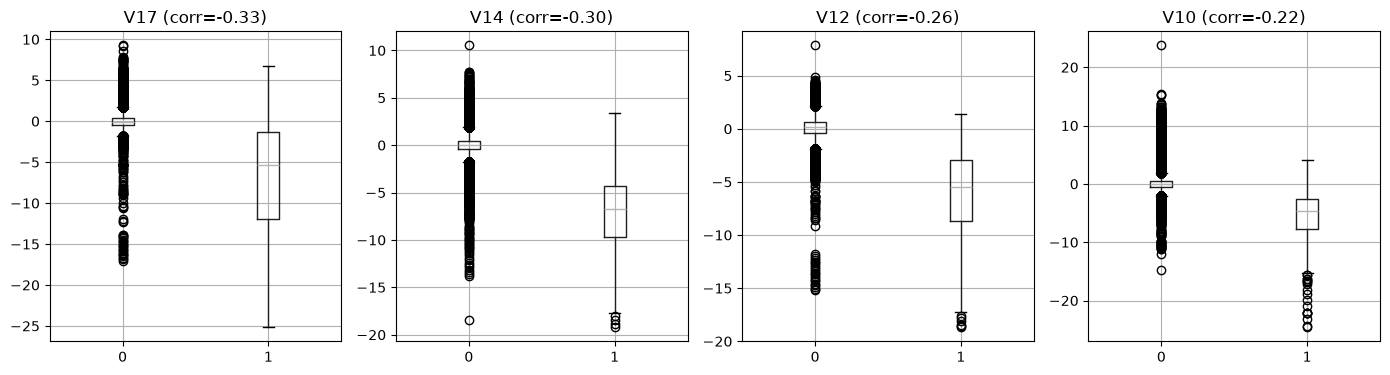

In [8]:
top4 = corr_with_class.head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, top4):
    df.boxplot(column=col, by='Class', ax=ax)
    ax.set_title(f'{col} (corr={corr_with_class[col]:.2f})')
    ax.set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Summary of observations

1. **Extreme class imbalance.** 492 of 284,807 transactions are fraud (0.1727%). A dummy classifier that always predicts "not fraud" scores 99.83% accuracy while catching zero fraud — accuracy is unusable as a metric for this problem and won't be used in later phases.

2. **`Amount` gives a weak, mixed signal.** Fraud's median amount (9.25) is *lower* than legit's (22.00) — most fraud is small-value — but fraud's mean (122.21) is *higher* than legit's mean (88.29) because of a handful of larger frauds. Fraud amounts never exceed ~2,125, while legit amounts go up to 25,691. (Currency unit isn't specified in the dataset; it's a European bank dataset so likely EUR, not INR.) Worth keeping as a feature, not a strong standalone predictor.

3. **Fraud rate is not flat over time, but the evidence for "real" drift is ambiguous.** Hourly fraud rate ranges from 0% to 2.05% (mean 0.27%), with a tendency to spike during low-volume overnight hours. However, each hourly bin only contains ~10 frauds on average, so a meaningful part of this swing could just be small-sample statistical noise rather than a genuine change in fraud behavior. This needs a more rigorous test in Phase 3, not a conclusion drawn from a chart alone.

4. **The anonymized `V1`-`V28` features do carry real signal.** `V17`, `V14`, `V12`, and `V10` show the strongest correlation with `Class` (|r| between 0.22 and 0.33) and visibly separate the two classes in their distributions. We can't interpret what these components represent, but they're clearly usable for modeling.

5. **Transaction volume follows a clear day/night cycle**, confirming the dataset genuinely spans two real calendar days rather than being a random shuffle of transactions. This matters for Phase 2: a time-based train/test split needs to account for this cycle rather than splitting at an arbitrary point that might land at a low-volume trough.

**Caveat for the whole notebook:** with only 492 fraud examples total, any statistic broken down further (by hour, by amount bucket, etc.) is working with a small sample and should be read as suggestive, not definitive.